# Анализ интервью (Автономия)
Этот блокнот загружает данные интревью, кодирует по категориям и визуализирует результаты.

In [ ]:
!pip install pandas openpyxl matplotlib seaborn

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap

In [ ]:
file_path = "/content/Copy of Автономия Интервью.xlsx"
sheet1_df = pd.read_excel(file_path, sheet_name="Интервью")

sheet1_df = sheet1_df.rename (columns ={"Вопросы / Интервью": "Вопрос_интервью"})
sheet1_long = sheet1_df.melt(id_vars=["Вопрос_интервью"], var_name="Респонеднт", value_name="Ответ").dropna(subset=["Ответ"])

coding_dictionary = {
    "Осознание целей и планирование": [
        "цели", "цель", "план", "планирование", "график", "временные блоки", "заранее",
        "понимать", "зачем", "структура", "организовать", "осознание", "понимание", "целей", "перед"
    ],
    "Самостоятельность в действиях": [
        "самостоятельность", "сам", "самопроверка", "самоконтроль", "остаться", "дополнительный",
        "свои", "делать", "понял", "исправить", "самостоятельно", "инициативу", "инициатива", "уметь", "попробовать"
    ],
    "Внутренняя мотивация и интерес": [
        "интерес", "интересно", "инициативность", "желание", "мотивация", "любопытство",
        "хотят", "захотели", "предлагать", "тема", "сами", "интересуется", "предлагают", "хочется"
    ],
    "Использование цифровых ресурсов": [
        "сайт", "вкладки", "гугл", "скриншот", "ссылки", "интернет", "пользоваться",
        "находить", "искать", "онлайн", "чат", "работать онлайн", "интернете", "ресурсы"
    ],
    "Организация учебной деятельности": [
        "дз", "домашка", "домашнее", "структурировано", "фото", "прикрепить", "оформление",
        "четко", "красиво", "дизайн", "делают", "присылают", "выполнения"
    ],
    "Взаимодействие с преподавателем": [
        "преподаватель", "учитель", "подсказать", "советовать", "показать", "выбор",
        "проговорить", "разъяснить", "алгоритм", "помощь", "обратная связь", "запросить",
        "помочь", "просить", "советы", "помощью"
    ],
    "Ограничения и трудности": [
        "лень", "забывают", "хуже", "списывать", "трудно", "проблемы", "меньше",
        "не хотят", "сложности", "нет разницы", "плохо", "трудно", "раньше", "требований", "ответственности"
    ],
    "Метакогнитивный контроль (проверка понимания)": [
        "понять", "поняли", "осознание", "что значит", "значение", "проверять",
        "что именно", "понимают", "проверка"
    ],
    "Социальное взаимодействие": [
        "группа", "друг другу", "вместе", "в паре", "взаимодействие", "обсуждают",
        "делятся", "обсуждение"
    ],
    "Рефлексия и самооценка": [
        "рефлексия", "рефлексировать", "размышлять", "самооценка", "оценить себя",
        "анализ", "проанализировать", "разобрать", "осознал", "осознание опыта",
        "осмысление", "что получилось", "что не получилось", "понял свои ошибки",
        "обратиться к себе", "переосмысление"
    ]
}


In [ ]:

def code_answer(text):
    text_lower = str(text).lower()
    codes = []
    for cat, keywords in coding_dictionary.items():
        if any(kw in text_lower for kw in keywords):
            codes.append(cat)
    return codes if codes else ["Другое"]

sheet1_long["Категория"] = sheet1_long["Ответ"].apply(code_answer)
sheet1_exploded = sheet1_long.explode("Категория")
sheet1_exploded = sheet1_exploded[~sheet1_exploded["Категория"].isin(["Другое", "Другое / уникальные случаи"])]

category_counts_sheet1 = sheet1_exploded["Категория"].value_counts()


/tmp/ipykernel_882/1906273905.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x=category_counts_sheet1.index, y=category_counts_sheet1.values, palette="viridis")


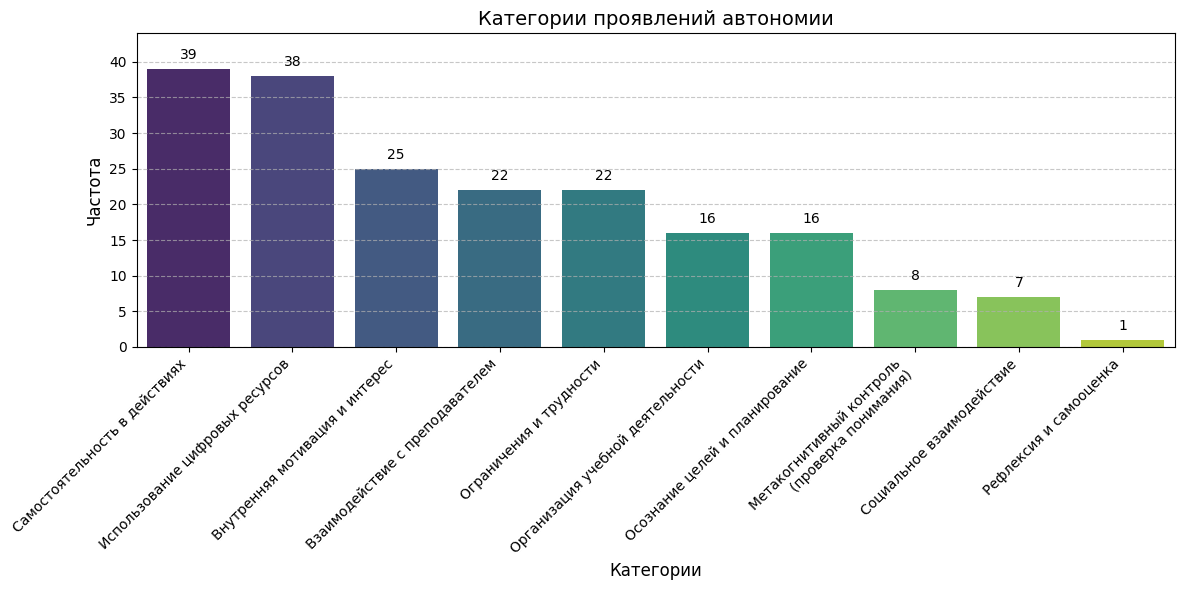

In [ ]:
category_counts_sheet1.index = [
    c.replace(
        "Метакогнитивный контроль (проверка понимания)",
        "Метакогнитивный контроль\n(проверка понимания)"
    )
    for c in category_counts_sheet1.index
]
plt.figure(figsize=(12, 6))
barplot = sns.barplot(x=category_counts_sheet1.index, y=category_counts_sheet1.values, palette="viridis")
plt.ylim(0, max(category_counts_sheet1.values)+5)
plt.title("Категории проявлений автономии", fontsize=14)
plt.xlabel("Категории", fontsize=12)
plt.ylabel("Частота", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.7)

for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.0f'), (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=10, color='black')

plt.tight_layout()
plt.show()


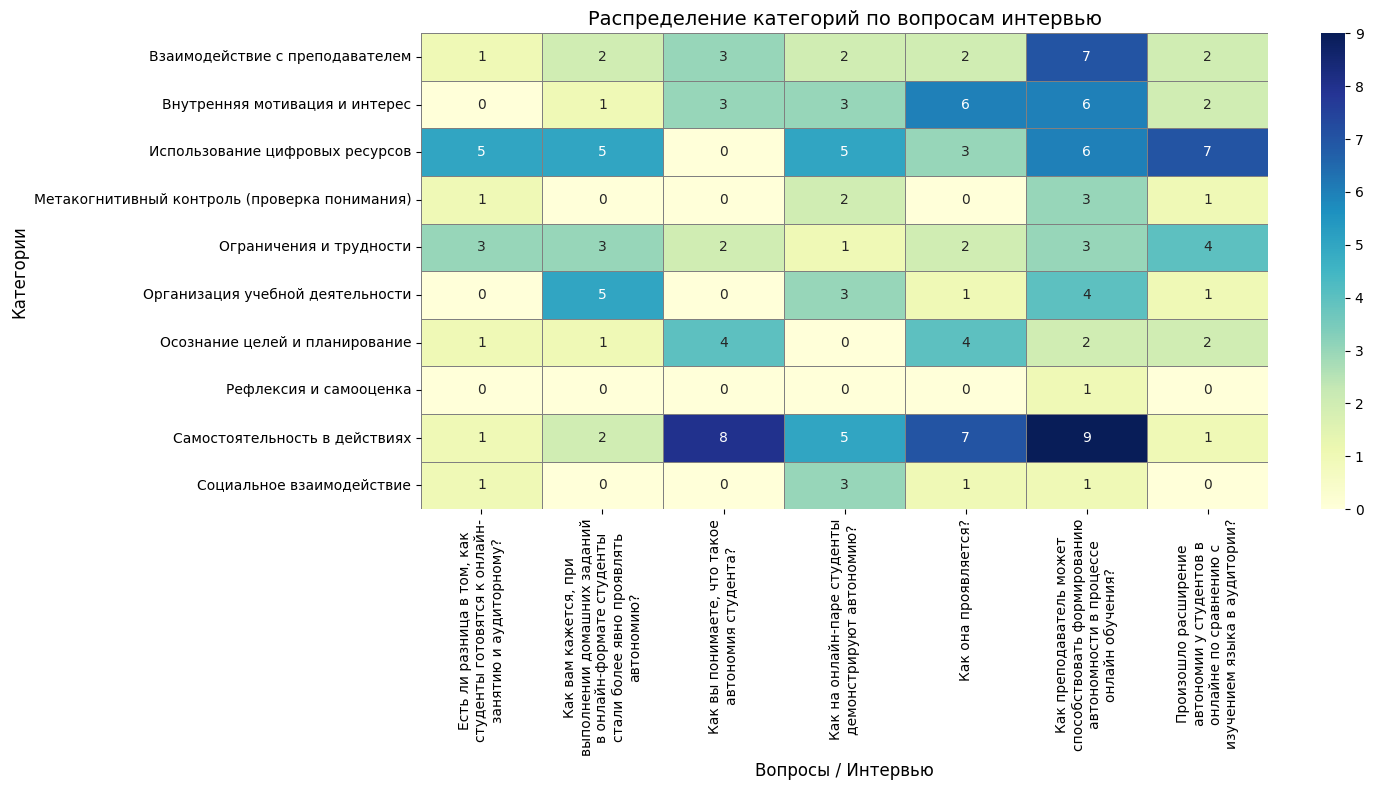

In [ ]:

# Вопросы / Интервью = будущая ось X
# имена респондентов = просто техническая колонка, в график не попадет
sheet1_long = sheet1_df.melt(
    id_vars=["Вопросы / Интервью"],
    var_name="Респондент",
    value_name="Ответ"
).dropna(subset=["Ответ"])

# кодирование категорий
def assign_categories(text, coding_dictionary):
    text = str(text).lower()
    found = []
    for category, keywords in coding_dictionary.items():
        if any(keyword in text for keyword in keywords):
            found.append(category)
    return found if found else ["Другое"]

sheet1_long["Категория"] = sheet1_long["Ответ"].apply(
    lambda x: assign_categories(x, coding_dictionary)
)

# разворачиваем списки категорий
sheet1_exploded = sheet1_long.explode("Категория")

# если "Другое" не нужно
sheet1_exploded = sheet1_exploded[sheet1_exploded["Категория"] != "Другое"]

# таблица для heatmap:
# Y = категории
# X = вопросы / интервью
category_table_sheet1 = sheet1_exploded.pivot_table(
    index="Категория",
    columns="Вопросы / Интервью",
    aggfunc="size",
    fill_value=0
)
if "Заметки" in category_table_sheet1.columns:
    category_table_sheet1 = category_table_sheet1.drop(columns=["Заметки"])

# перенос длинных подписей вопросов
def wrap_labels(label, width=28):
    return "\n".join(textwrap.wrap(str(label), width=width))


category_table_sheet1.columns = [
    wrap_labels(q, width=28) for q in category_table_sheet1.columns
]

# heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(
    category_table_sheet1,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    linewidths=0.5,
    linecolor="gray"
)

plt.title("Распределение категорий по вопросам интервью", fontsize=14)
plt.ylabel("Категории", fontsize=12)
plt.xlabel("Вопросы / Интервью", fontsize=12)
plt.xticks(rotation=90, ha="center")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()